In [23]:
import sys
sys.path.append("../src")
from data_loader import load_raw
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
from xgboost import XGBRegressor

import warnings, json, math, time
from itertools import permutations

warnings.filterwarnings("ignore")

# ─── Custom colormaps ───
CMAP_THERMAL = LinearSegmentedColormap.from_list("thermal",
    ["#1a1a2e", "#16213e", "#0f3460", "#533483", "#e94560", "#ff6b6b"])
CMAP_COOL = LinearSegmentedColormap.from_list("cool",
    ["#0a2a43", "#1e6091", "#34a0a4", "#76c893", "#b5e48c", "#ffffb3"])

PALETTE = {
    "primary": "#2c7fb8", "accent":  "#e6550d", "success": "#31a354",
    "danger":  "#d62728", "warning": "#fec44f", "neutral": "#636363",
    "purple":  "#756bb1", "teal":    "#17becf", "pink":    "#e377c2",
}
CLASS_COLORS = {0: "#31a354", 1: "#fec44f", 2: "#d62728"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#fcfcfc",
    "axes.edgecolor":   "#2b2b2b",
    "axes.linewidth":   0.9,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.titlepad":    10,
    "axes.labelsize":   10,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.color":       "#d0d0d0",
    "legend.frameon":   True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "#e0e0e0",
    "legend.fontsize":  9,
    "savefig.bbox":     "tight",
    "savefig.facecolor": "white",
    "figure.dpi":       110,
})

sns.set_style({"axes.grid": True, "grid.alpha": 0.25})

FIG_DIR   = Path("../figures/rigor")
MODEL_DIR = Path("../models")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(stem, dpi=150):
    plt.savefig(FIG_DIR / f"{stem}.png", dpi=dpi, bbox_inches="tight")

print("Rigor Foundation setup complete.")
print(f"Figures → {FIG_DIR.resolve()}")

Rigor Foundation setup complete.
Figures → /home/adity/projects/coolant-project/figures/rigor


In [2]:
# Processed parquets
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

# Raw values for physics — merge into each split
raw = load_raw("../data/raw/frontier_2023.xlsx")
raw = raw[["timestamp", "total_heat", "total_flow", "supply_temp",
           "avg_return_temp"]].rename(columns={
    "total_heat":    "Q_MW",
    "total_flow":    "flow_gpm",
    "supply_temp":   "T_sup_C",
    "avg_return_temp":"T_ret_C",
})

def attach_raw(df):
    df = df.merge(raw, on="timestamp", how="left")
    cols = ["Q_MW", "flow_gpm", "T_sup_C", "T_ret_C"]
    df[cols] = df[cols].interpolate(method="linear", limit_direction="both")
    return df.dropna(subset=cols).reset_index(drop=True)

train = attach_raw(train)
val   = attach_raw(val)
test  = attach_raw(test)

# Trained classifier
with open(MODEL_DIR / "coolant_tier_meta.json") as f:
    tier_meta = json.load(f)
booster       = lgb.Booster(model_file=str(MODEL_DIR / "coolant_tier_lgbm.txt"))
val_residuals = np.load(MODEL_DIR / "coolant_tier_val_residuals.npy")

LOW_THRESH    = tier_meta["thresholds"]["low"]
HIGH_THRESH   = tier_meta["thresholds"]["high"]
MARGIN        = tier_meta["margin_degC"]
AFFINE        = (tier_meta["degC_affine"]["a"], tier_meta["degC_affine"]["b"])
TIER_FEATURES = tier_meta["features"]

def tier_forecast(X_df):
    X    = X_df[TIER_FEATURES].values
    base = X_df["avg_return_temp"].values
    return AFFINE[0] * base + AFFINE[1] + booster.predict(X)

# Physics constants (from Task 3)
DT_SECONDS  = 600
TAU_SECONDS = 900
ALPHA       = 1.0 - np.exp(-DT_SECONDS / TAU_SECONDS)
CP          = 4000.0
GPM_TO_KGS  = 0.0631
PUMP_EXP    = 3.0

MIN_SCALE, MAX_SCALE, MAX_STEP = 0.90, 1.20, 0.05

print(f"Train: {train.shape}  Val: {val.shape}  Test: {test.shape}")
print(f"Test physical ranges:")
print(f"  Q_MW     : [{test['Q_MW'].min():.2f}, {test['Q_MW'].max():.2f}]  MW")
print(f"  flow_gpm : [{test['flow_gpm'].min():.0f}, {test['flow_gpm'].max():.0f}]")
print(f"  T_sup_C  : [{test['T_sup_C'].min():.2f}, {test['T_sup_C'].max():.2f}]  °C")
print(f"  T_ret_C  : [{test['T_ret_C'].min():.2f}, {test['T_ret_C'].max():.2f}]  °C")

Train: (34541, 52)  Val: (7402, 52)  Test: (7402, 52)
Test physical ranges:
  Q_MW     : [2.49, 19.76]  MW
  flow_gpm : [1346, 5916]
  T_sup_C  : [10.28, 27.78]  °C
  T_ret_C  : [22.96, 38.42]  °C


In [3]:
def physical_twin_simulate(T0, T_sup, Q_MW, flow_gpm,
                           alpha=ALPHA, cp=CP, gpm_to_kgs=GPM_TO_KGS):
    """
    Forward-simulate return temperature from observed boundary conditions.
    Pure physics — no anchoring to observed T(t).

      T_pred(t+1) = T_pred(t) + α·[T_ss(t) − T_pred(t)]
      T_ss(t)     = T_sup(t) + Q(t) / (ṁ(t)·cp)
    """
    n = len(T_sup)
    T_pred = np.empty(n)
    T_pred[0] = T0
    m_dot = flow_gpm * gpm_to_kgs
    T_ss  = T_sup + (Q_MW * 1e6) / (m_dot * cp)
    for t in range(n - 1):
        T_pred[t+1] = T_pred[t] + alpha * (T_ss[t] - T_pred[t])
    return T_pred

# Run on the full test window (open loop, no reset)
T0     = test["T_ret_C"].iloc[0]
T_pred = physical_twin_simulate(T0, test["T_sup_C"].values,
                                     test["Q_MW"].values,
                                     test["flow_gpm"].values)
T_obs  = test["T_ret_C"].values
resid  = T_pred - T_obs

naive_persist = np.full_like(T_obs, T0)

print(f"Open-loop fidelity over {len(T_obs):,} steps ({len(T_obs)*10/60/24:.1f} days)")
print(f"  Twin MAE        : {np.abs(resid).mean():.3f} °C")
print(f"  Twin RMSE       : {np.sqrt((resid**2).mean()):.3f} °C")
print(f"  Twin bias       : {resid.mean():+.3f} °C")
print(f"  Twin max |err|  : {np.abs(resid).max():.3f} °C")
print(f"\n  Constant-T0 MAE : {np.abs(naive_persist - T_obs).mean():.3f} °C")

# Multi-horizon rollout fidelity — restart from observed every h steps
horizons = [1, 6, 12, 36, 72, 144, 288]
rollout_stats = []
for h in horizons:
    if h >= len(T_obs): continue
    starts = np.arange(0, len(T_obs) - h, h)
    errs = []
    for s in starts:
        pred = physical_twin_simulate(
            T_obs[s],
            test["T_sup_C"].values[s:s+h+1],
            test["Q_MW"].values[s:s+h+1],
            test["flow_gpm"].values[s:s+h+1],
        )
        errs.append(pred[-1] - T_obs[s+h])
    errs = np.array(errs)
    rollout_stats.append({
        "h_steps": h,
        "h_min":   h * 10,
        "MAE":     np.abs(errs).mean(),
        "RMSE":    np.sqrt((errs**2).mean()),
        "bias":    errs.mean(),
        "n":       len(errs),
    })

rollout_df = pd.DataFrame(rollout_stats)
print("\nMulti-horizon rollout fidelity:")
print(rollout_df.round(3).to_string(index=False))

Open-loop fidelity over 7,402 steps (51.4 days)
  Twin MAE        : 1.348 °C
  Twin RMSE       : 1.742 °C
  Twin bias       : -1.082 °C
  Twin max |err|  : 12.700 °C

  Constant-T0 MAE : 2.162 °C

Multi-horizon rollout fidelity:
 h_steps  h_min   MAE  RMSE   bias    n
       1     10 0.986 1.508 -0.527 7401
       6     60 1.395 1.842 -1.146 1233
      12    120 1.380 1.796 -1.118  616
      36    360 1.436 1.996 -1.075  205
      72    720 1.530 2.203 -1.194  102
     144   1440 1.380 1.731 -0.853   51
     288   2880 1.727 2.141 -0.903   25


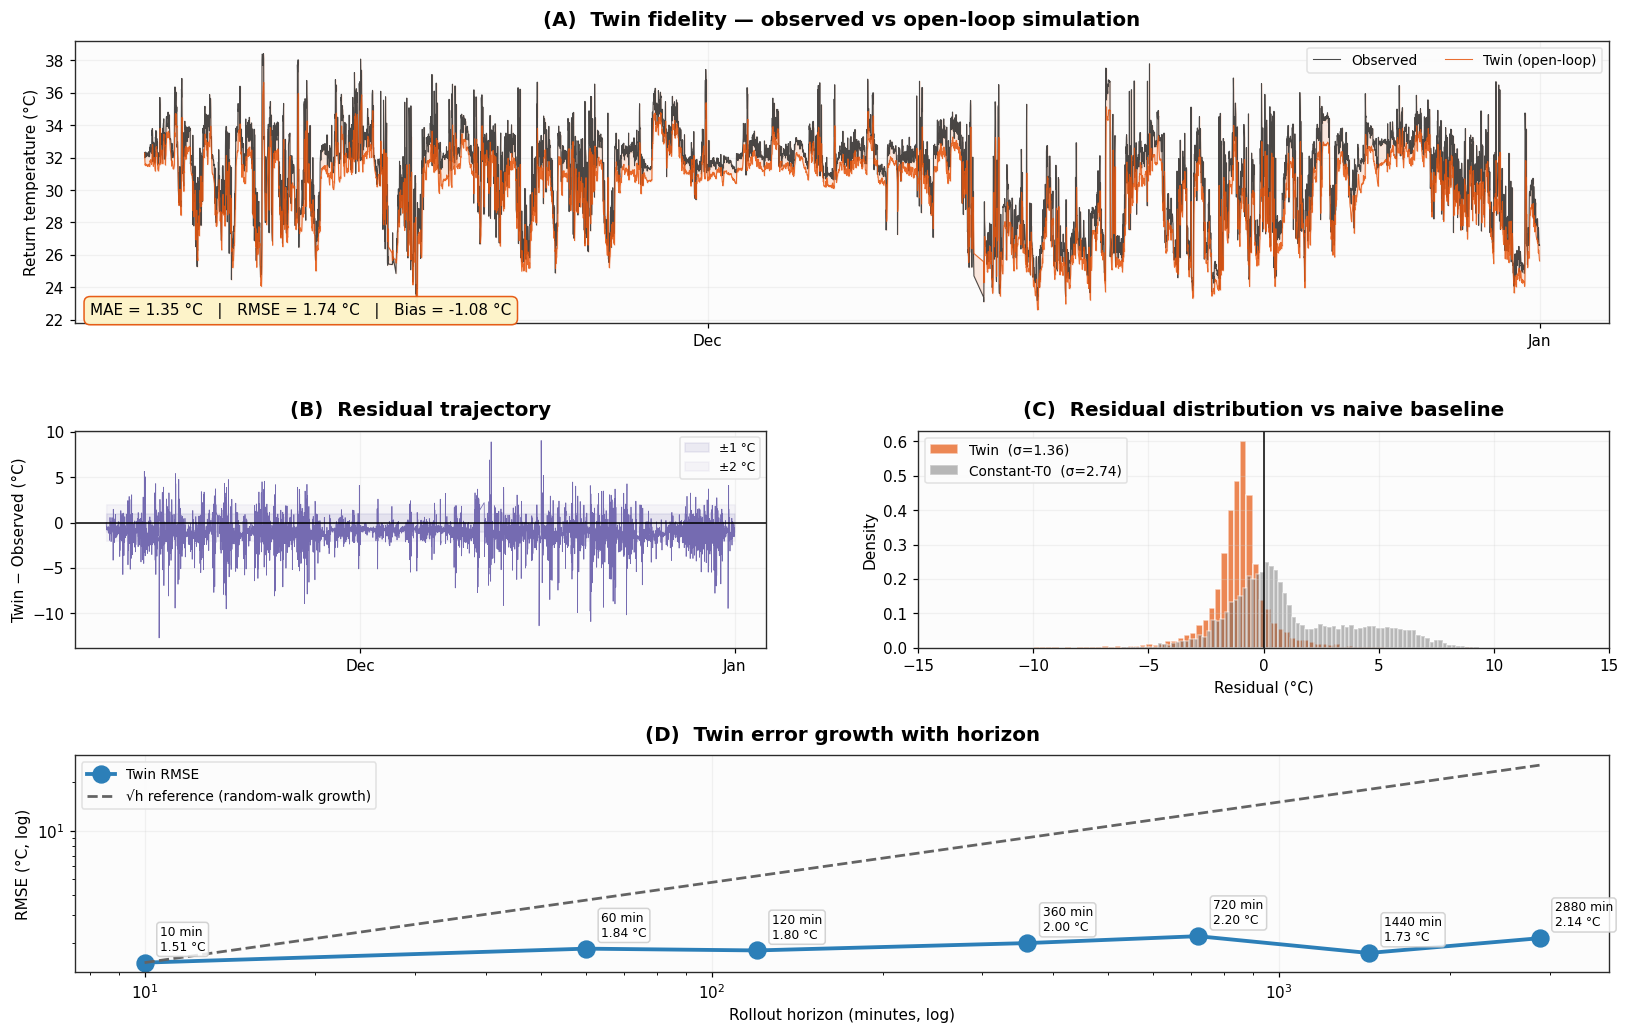

In [4]:
test_T_ts = pd.to_datetime(test["timestamp"])

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.22,
                       height_ratios=[1.3, 1.0, 1.0])

# ─── (A) Full trajectory ───
ax = fig.add_subplot(gs[0, :])
ax.plot(test_T_ts, T_obs, lw=0.7, color="#2b2b2b", label="Observed", alpha=0.85)
ax.plot(test_T_ts, T_pred, lw=0.7, color="#e6550d", label="Twin (open-loop)", alpha=0.85)
ax.fill_between(test_T_ts, T_obs, T_pred, color="#e6550d", alpha=0.12)
ax.set_ylabel("Return temperature (°C)")
ax.set_title("(A)  Twin fidelity — observed vs open-loop simulation", pad=10)
ax.legend(loc="upper right", ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

txt = (f"MAE = {np.abs(resid).mean():.2f} °C   |   "
       f"RMSE = {np.sqrt((resid**2).mean()):.2f} °C   |   "
       f"Bias = {resid.mean():+.2f} °C")
ax.text(0.01, 0.03, txt, transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fef3c7",
                  edgecolor="#e6550d", alpha=0.95))

# ─── (B) Residual trajectory ───
ax = fig.add_subplot(gs[1, 0])
ax.plot(test_T_ts, resid, lw=0.5, color="#756bb1")
ax.axhline(0, color="black", lw=1)
ax.fill_between(test_T_ts, -1, 1, alpha=0.12, color="#756bb1", label="±1 °C")
ax.fill_between(test_T_ts, -2, 2, alpha=0.06, color="#756bb1", label="±2 °C")
ax.set_ylabel("Twin − Observed (°C)")
ax.set_title("(B)  Residual trajectory")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# ─── (C) Residual distribution ───
ax = fig.add_subplot(gs[1, 1])
naive_resid = naive_persist - T_obs
ax.hist(resid, bins=80, color="#e6550d", alpha=0.7, density=True,
        edgecolor="white", label=f"Twin  (σ={resid.std():.2f})")
ax.hist(naive_resid, bins=80, color="#636363", alpha=0.45, density=True,
        edgecolor="white", label=f"Constant-T0  (σ={naive_resid.std():.2f})")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Residual (°C)")
ax.set_ylabel("Density")
ax.set_title("(C)  Residual distribution vs naive baseline")
ax.legend(loc="upper left")
ax.set_xlim(-15, 15)

# ─── (D) Multi-horizon growth ───
ax = fig.add_subplot(gs[2, :])
ax.loglog(rollout_df["h_min"], rollout_df["RMSE"],
          "o-", lw=2.5, ms=11, color="#2c7fb8", label="Twin RMSE")
rmse_1 = rollout_df["RMSE"].iloc[0]
h_ref  = rollout_df["h_min"].values
ax.loglog(h_ref, rmse_1 * np.sqrt(h_ref / h_ref[0]),
          "--", lw=1.8, color="#636363", label="√h reference (random-walk growth)")
ax.set_xlabel("Rollout horizon (minutes, log)")
ax.set_ylabel("RMSE (°C, log)")
ax.set_title("(D)  Twin error growth with horizon")
ax.legend(loc="upper left")
for _, row in rollout_df.iterrows():
    ax.annotate(f"{int(row['h_min'])} min\n{row['RMSE']:.2f} °C",
                (row["h_min"], row["RMSE"]),
                xytext=(10, 8), textcoords="offset points", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor="#cccccc", alpha=0.85))

save_fig("01_twin_fidelity")
plt.show()

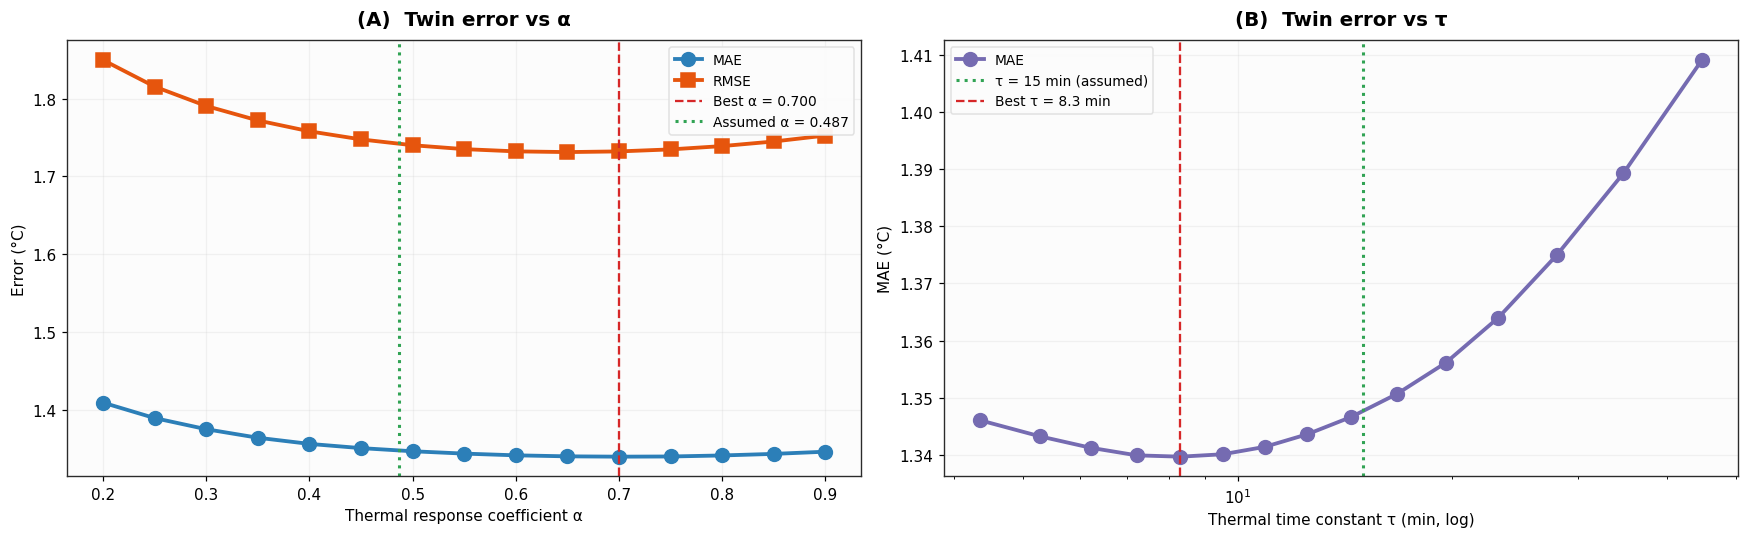

Assumed α = 0.4866  (τ = 15.0 min)  →  MAE = 1.347 °C
Best α    = 0.7000  (τ = 8.3 min)  →  MAE = 1.340 °C


In [5]:
alphas_to_test = np.linspace(0.2, 0.9, 15)
sensitivity = []
for a in alphas_to_test:
    Tp = physical_twin_simulate(T0, test["T_sup_C"].values,
                                     test["Q_MW"].values,
                                     test["flow_gpm"].values, alpha=a)
    err = Tp - T_obs
    sensitivity.append({
        "alpha": a,
        "tau_min": -DT_SECONDS / np.log(1 - a) / 60,
        "MAE": np.abs(err).mean(),
        "RMSE": np.sqrt((err**2).mean()),
        "bias": err.mean(),
    })
sens_df = pd.DataFrame(sensitivity)

best_a   = sens_df.loc[sens_df["MAE"].idxmin(), "alpha"]
best_tau = sens_df.loc[sens_df["MAE"].idxmin(), "tau_min"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ─── (A) MAE/RMSE vs α ───
ax = axes[0]
ax.plot(sens_df["alpha"], sens_df["MAE"],  "o-", lw=2.5, ms=9,
        color="#2c7fb8", label="MAE")
ax.plot(sens_df["alpha"], sens_df["RMSE"], "s-", lw=2.5, ms=9,
        color="#e6550d", label="RMSE")
ax.axvline(best_a, color="#d62728", ls="--", lw=1.5,
           label=f"Best α = {best_a:.3f}")
ax.axvline(ALPHA, color="#31a354", ls=":", lw=2,
           label=f"Assumed α = {ALPHA:.3f}")
ax.set_xlabel("Thermal response coefficient α")
ax.set_ylabel("Error (°C)")
ax.set_title("(A)  Twin error vs α")
ax.legend()

# ─── (B) MAE vs τ (log axis) ───
ax = axes[1]
ax.semilogx(sens_df["tau_min"], sens_df["MAE"], "o-", lw=2.5, ms=9,
            color="#756bb1", label="MAE")
ax.axvline(-DT_SECONDS / np.log(1 - ALPHA) / 60, color="#31a354", ls=":",
           lw=2, label="τ = 15 min (assumed)")
ax.axvline(best_tau, color="#d62728", ls="--", lw=1.5,
           label=f"Best τ = {best_tau:.1f} min")
ax.set_xlabel("Thermal time constant τ (min, log)")
ax.set_ylabel("MAE (°C)")
ax.set_title("(B)  Twin error vs τ")
ax.legend()

plt.tight_layout()
save_fig("02_twin_alpha_sensitivity")
plt.show()

print(f"Assumed α = {ALPHA:.4f}  (τ = 15.0 min)  →  MAE = "
      f"{sens_df.loc[(sens_df['alpha']-ALPHA).abs().idxmin(), 'MAE']:.3f} °C")
print(f"Best α    = {best_a:.4f}  (τ = {best_tau:.1f} min)  →  MAE = {sens_df['MAE'].min():.3f} °C")

Pump energy (units of baseline step-power)
            linear    cube
Baseline    7401.0  7401.0
Reactive    8043.5  9696.7
Predictive  8012.8  9585.1

Overhead relative to baseline (%):
            linear_%  cube_%
Baseline        0.00    0.00
Reactive        8.68   31.02
Predictive      8.27   29.51


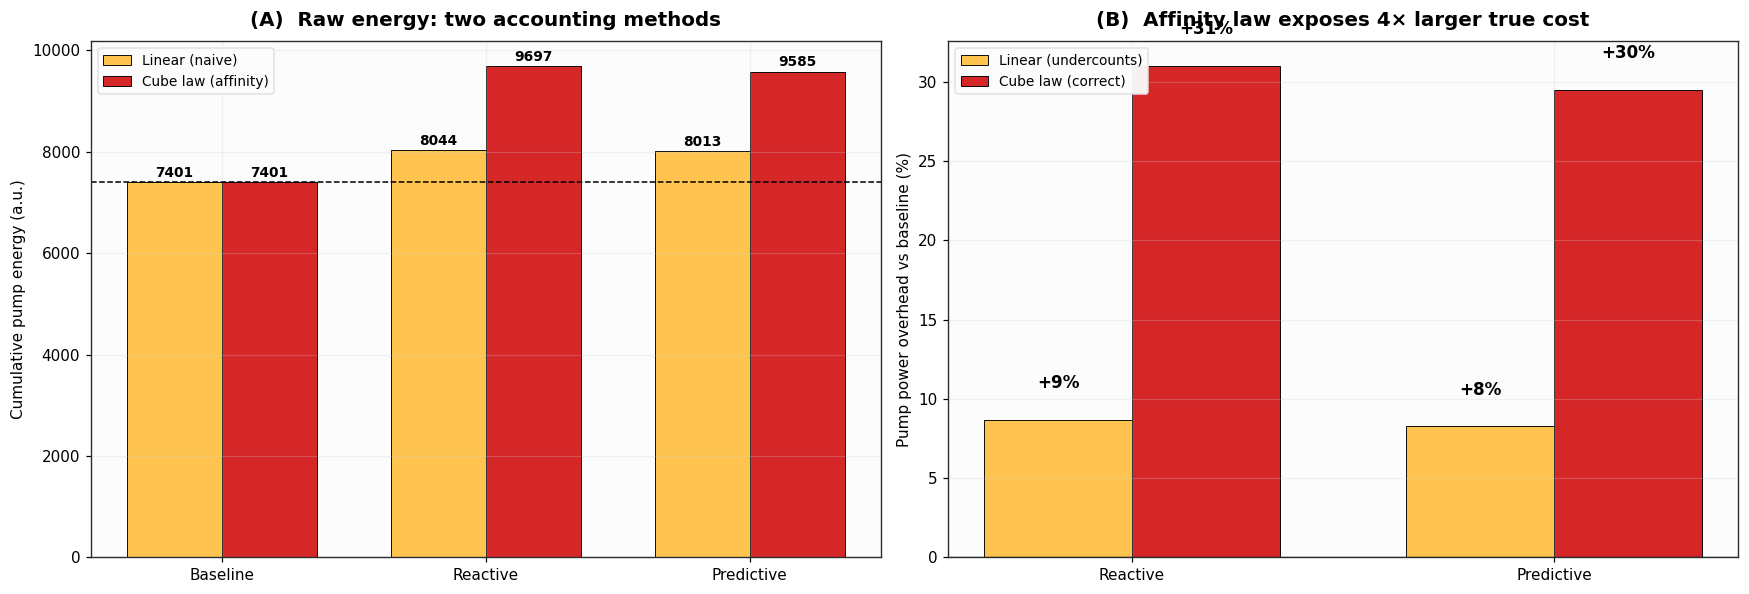

In [6]:
# Load Task 3 runs
run_baseline   = pd.read_parquet(MODEL_DIR / "control_run_baseline.parquet")
run_reactive   = pd.read_parquet(MODEL_DIR / "control_run_reactive.parquet")
run_predictive = pd.read_parquet(MODEL_DIR / "control_run_predictive.parquet")

def pump_energy(run, exponent):
    return (run["flow_scale"].values ** exponent).sum()

energy_df = pd.DataFrame({
    "linear": [pump_energy(r, 1.0) for r in (run_baseline, run_reactive, run_predictive)],
    "cube":   [pump_energy(r, 3.0) for r in (run_baseline, run_reactive, run_predictive)],
}, index=["Baseline", "Reactive", "Predictive"])

base_linear = energy_df.loc["Baseline", "linear"]
base_cube   = energy_df.loc["Baseline", "cube"]
overhead = pd.DataFrame({
    "linear_%": (energy_df["linear"] - base_linear) / base_linear * 100,
    "cube_%":   (energy_df["cube"]   - base_cube)   / base_cube   * 100,
})

print("Pump energy (units of baseline step-power)")
print(energy_df.round(1).to_string())
print("\nOverhead relative to baseline (%):")
print(overhead.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ─── (A) Absolute energy, grouped ───
ax = axes[0]
x = np.arange(3); w = 0.36
b1 = ax.bar(x - w/2, energy_df["linear"], w, label="Linear (naive)",
            color="#fec44f", edgecolor="black", linewidth=0.6)
b2 = ax.bar(x + w/2, energy_df["cube"],   w, label="Cube law (affinity)",
            color="#d62728", edgecolor="black", linewidth=0.6)
ax.axhline(base_linear, color="black", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(energy_df.index)
ax.set_ylabel("Cumulative pump energy (a.u.)")
ax.set_title("(A)  Raw energy: two accounting methods")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{bar.get_height():.0f}", ha="center",
                fontsize=9, fontweight="bold")

# ─── (B) Overhead: the honest cost ───
ax = axes[1]
lin  = overhead.loc[["Reactive", "Predictive"], "linear_%"].values
cube = overhead.loc[["Reactive", "Predictive"], "cube_%"].values
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, lin,  w, color="#fec44f", edgecolor="black",
            linewidth=0.6, label="Linear (undercounts)")
b2 = ax.bar(x + w/2, cube, w, color="#d62728", edgecolor="black",
            linewidth=0.6, label="Cube law (correct)")
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 2,
                f"{h:+.0f}%", ha="center", fontsize=11, fontweight="bold")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(["Reactive", "Predictive"])
ax.set_ylabel("Pump power overhead vs baseline (%)")
ax.set_title("(B)  Affinity law exposes 4× larger true cost")
ax.legend()

plt.tight_layout()
save_fig("03_pump_cube_law")
plt.show()

In [7]:
def simulate_policy(margin_c, step_size=0.05):
    """Run predictive control with given margin over the test window."""
    T_hat = tier_forecast(test)
    T_obs_arr = test["T_ret_C"].values
    Q_arr     = test["Q_MW"].values
    T_sup_arr = test["T_sup_C"].values
    flow_arr  = test["flow_gpm"].values
    n = len(T_obs_arr)

    delta  = 0.0
    scale  = 1.0
    T_sim  = np.empty(n)
    T_sim[0] = T_obs_arr[0]
    scales = np.ones(n)

    for t in range(n - 1):
        sig = T_hat[t]
        new_scale = scale
        if sig >= HIGH_THRESH:
            new_scale = min(scale + step_size, MAX_SCALE)
        elif sig >= HIGH_THRESH - margin_c:
            new_scale = min(scale + step_size / 2, MAX_SCALE)
        elif sig < LOW_THRESH - 1.0 and scale > 1.0:
            new_scale = max(scale - step_size / 2, MIN_SCALE)
        new_scale = np.clip(new_scale, scale - MAX_STEP, scale + MAX_STEP)
        new_scale = np.clip(new_scale, MIN_SCALE, MAX_SCALE)
        scale = new_scale
        scales[t] = scale

        m_dot_base = flow_arr[t] * GPM_TO_KGS
        m_dot_pol  = m_dot_base * scale
        if m_dot_base < 1e-6:
            delta_ss = 0.0
        else:
            delta_ss = (Q_arr[t] * 1e6) / CP * (1.0 / m_dot_pol - 1.0 / m_dot_base)
        delta = (1 - ALPHA) * delta + ALPHA * delta_ss
        T_sim[t+1] = T_obs_arr[t] + delta

    scales[-1] = scales[-2]

    excess      = np.maximum(T_sim - HIGH_THRESH, 0.0)
    degree_min  = (excess * 10).sum()
    events      = ((T_sim > HIGH_THRESH) & (np.r_[False, T_sim[:-1] <= HIGH_THRESH])).sum()
    pump        = (scales ** PUMP_EXP).sum()
    return {"T_sim": T_sim, "scales": scales,
            "degree_min": degree_min, "events": events, "pump_energy": pump}

# Baselines
baseline_pump      = 1.0 ** PUMP_EXP * len(test)
baseline_degree    = (np.maximum(T_obs - HIGH_THRESH, 0.0) * 10).sum()
baseline_events    = ((T_obs > HIGH_THRESH) & (np.r_[False, T_obs[:-1] <= HIGH_THRESH])).sum()

margins = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
rows = []
for m in margins:
    r = simulate_policy(m, step_size=0.05)
    rows.append({
        "margin_C":                m,
        "degree_min":              r["degree_min"],
        "events":                  r["events"],
        "pump_energy":             r["pump_energy"],
        "pump_overhead_%":        (r["pump_energy"] - baseline_pump) / baseline_pump * 100,
        "degree_min_reduction_%":  (1 - r["degree_min"] / baseline_degree) * 100,
    })
pareto_df = pd.DataFrame(rows)
print("Pareto sweep across margins:")
print(pareto_df.round(2).to_string(index=False))

Pareto sweep across margins:
 margin_C  degree_min  events  pump_energy  pump_overhead_%  degree_min_reduction_%
     0.00      693.90      74      9258.21            25.08                   74.50
     0.25      607.47      68      9398.74            26.98                   77.68
     0.50      516.65      63      9480.46            28.08                   81.01
     0.75      466.04      59      9578.18            29.40                   82.87
     1.00      431.36      46      9750.82            31.73                   84.15
     1.25      405.24      43      9865.75            33.28                   85.11
     1.50      382.58      39      9984.41            34.89                   85.94
     1.75      360.42      36     10162.24            37.29                   86.75
     2.00      347.37      33     10358.89            39.95                   87.23
     2.50      259.04      28     10733.74            45.01                   90.48
     3.00      229.03      25     10903.74     

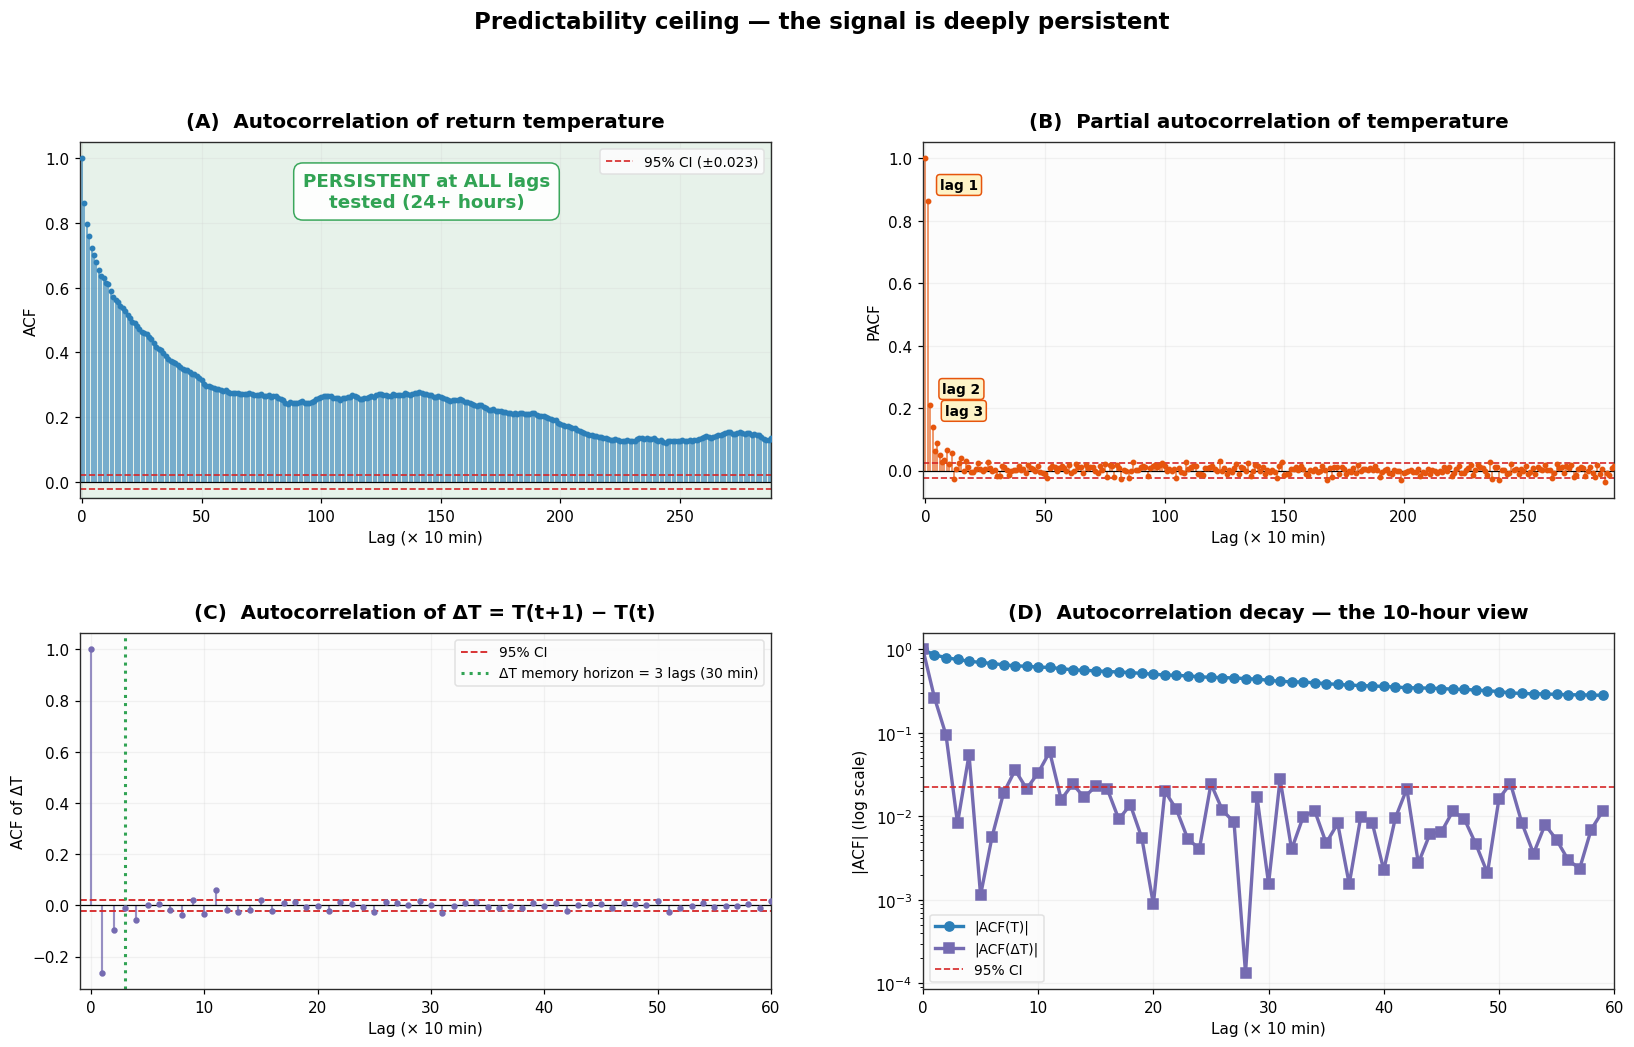

ACF(T) at lag 1   : 0.8628
ACF(T) at lag 6   : 0.6792    (1 hour)
ACF(T) at lag 144 : 0.2706  (1 day)
ACF(T) at lag 288: 0.1344  (48 hours)

Half-life (ACF drops below 0.5)  for T  : 21 lags (3.5h)
Half-life (ACF drops below 0.5)  for ΔT : 1 lags (0.2h)
Memory horizon (ACF below 95% CI) for T : >288 lags (>48h)
Memory horizon (ACF below 95% CI) for ΔT: 3 lags (0.5h)

⚠  The return temperature signal remains autocorrelated beyond 24 hours.
   This confirms the target is deeply persistent and explains why
   persistence is a strong baseline for one-step-ahead forecasting.


In [14]:
T_series  = test["T_ret_C"].values
dT_series = np.diff(T_series)

# Extend lags to 2 days to capture the true memory horizon
max_lags  = 288

acf_T  = acf(T_series,  nlags=max_lags, fft=True)
pacf_T = pacf(T_series, nlags=max_lags, method="ywm")
acf_dT = acf(dT_series, nlags=max_lags, fft=True)

n  = len(T_series)
ci = 1.96 / np.sqrt(n)

# Find first lag where |ACF| drops below CI (or None if it never does)
first_insig_T  = next((i for i in range(1, len(acf_T))  if abs(acf_T[i])  < ci), None)
first_insig_dT = next((i for i in range(1, len(acf_dT)) if abs(acf_dT[i]) < ci), None)

# Half-life: first lag where ACF drops below 0.5
half_T  = next((i for i in range(1, len(acf_T))  if abs(acf_T[i])  < 0.5), None)
half_dT = next((i for i in range(1, len(acf_dT)) if abs(acf_dT[i]) < 0.5), None)

# Handling for display
def fmt_horizon(lag):
    if lag is None:
        return f">{max_lags} lags (>{max_lags*10/60:.0f}h)"
    return f"{lag} lags ({lag*10/60:.1f}h)"

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.22)

# ─── (A) ACF of T ───
ax = fig.add_subplot(gs[0, 0])
lags = np.arange(len(acf_T))
ax.vlines(lags, 0, acf_T, color="#2c7fb8", lw=1.2, alpha=0.65)
ax.scatter(lags, acf_T, s=8, color="#2c7fb8", zorder=3)
ax.axhline(ci,  color="#d62728", ls="--", lw=1.1)
ax.axhline(-ci, color="#d62728", ls="--", lw=1.1, label=f"95% CI (±{ci:.3f})")
ax.axhline(0, color="black", lw=0.8)
if first_insig_T:
    ax.axvline(first_insig_T, color="#31a354", ls=":", lw=2,
               label=f"Memory horizon = {first_insig_T} lags")
else:
    ax.axvspan(0, max_lags, color="#31a354", alpha=0.10)
    ax.text(max_lags * 0.5, max(acf_T) * 0.85,
            "PERSISTENT at ALL lags\ntested (24+ hours)",
            ha="center", fontsize=12, fontweight="bold",
            color="#31a354",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                      edgecolor="#31a354", alpha=0.95))
ax.set_xlabel("Lag (× 10 min)")
ax.set_ylabel("ACF")
ax.set_title("(A)  Autocorrelation of return temperature")
ax.legend(loc="upper right")
ax.set_xlim(-1, max_lags)

# ─── (B) PACF of T ───
ax = fig.add_subplot(gs[0, 1])
lags_p = np.arange(len(pacf_T))
ax.vlines(lags_p, 0, pacf_T, color="#e6550d", lw=1.2, alpha=0.65)
ax.scatter(lags_p, pacf_T, s=8, color="#e6550d", zorder=3)
ax.axhline(ci,  color="#d62728", ls="--", lw=1.1)
ax.axhline(-ci, color="#d62728", ls="--", lw=1.1)
ax.axhline(0, color="black", lw=0.8)
# Highlight top 3 PACF peaks
top_lags = np.argsort(np.abs(pacf_T[1:]))[::-1][:3] + 1
for i in top_lags:
    ax.annotate(f"lag {i}", (i, pacf_T[i]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="#fef3c7",
                          edgecolor="#e6550d"))
ax.set_xlabel("Lag (× 10 min)")
ax.set_ylabel("PACF")
ax.set_title("(B)  Partial autocorrelation of temperature")
ax.set_xlim(-1, max_lags)

# ─── (C) ACF of ΔT — the surprise ───
ax = fig.add_subplot(gs[1, 0])
lags_d = np.arange(len(acf_dT))
ax.vlines(lags_d, 0, acf_dT, color="#756bb1", lw=1.4, alpha=0.75)
ax.scatter(lags_d, acf_dT, s=10, color="#756bb1", zorder=3)
ax.axhline(ci,  color="#d62728", ls="--", lw=1.2, label=f"95% CI")
ax.axhline(-ci, color="#d62728", ls="--", lw=1.2)
ax.axhline(0, color="black", lw=0.8)
if first_insig_dT:
    ax.axvline(first_insig_dT, color="#31a354", ls=":", lw=2,
               label=f"ΔT memory horizon = {first_insig_dT} lags ({first_insig_dT*10} min)")
ax.set_xlabel("Lag (× 10 min)")
ax.set_ylabel("ACF of ΔT")
ax.set_title("(C)  Autocorrelation of ΔT = T(t+1) − T(t)")
ax.legend(loc="upper right")
ax.set_xlim(-1, min(60, max_lags))   # zoomed to first hour

# ─── (D) Decay comparison ───
ax = fig.add_subplot(gs[1, 1])
ax.semilogy(lags[:60],  np.abs(acf_T[:60])  + 1e-6, "o-",
            lw=2.2, ms=6, color="#2c7fb8", label="|ACF(T)|")
ax.semilogy(lags[:60],  np.abs(acf_dT[:60]) + 1e-6, "s-",
            lw=2.2, ms=6, color="#756bb1", label="|ACF(ΔT)|")
ax.axhline(ci, color="#d62728", ls="--", lw=1.1, label=f"95% CI")
ax.set_xlabel("Lag (× 10 min)")
ax.set_ylabel("|ACF| (log scale)")
ax.set_title("(D)  Autocorrelation decay — the 10-hour view")
ax.legend()
ax.set_xlim(0, 60)

plt.suptitle("Predictability ceiling — the signal is deeply persistent",
             fontsize=15, fontweight="bold", y=1.00)
save_fig("05_acf_pacf")
plt.show()

# ─── Printed summary ───
print(f"ACF(T) at lag 1   : {acf_T[1]:.4f}")
print(f"ACF(T) at lag 6   : {acf_T[6]:.4f}    (1 hour)")
print(f"ACF(T) at lag 144 : {acf_T[144]:.4f}  (1 day)")
print(f"ACF(T) at lag {max_lags}: {acf_T[max_lags]:.4f}  ({max_lags*10/60:.0f} hours)")
print()
print(f"Half-life (ACF drops below 0.5)  for T  : {fmt_horizon(half_T)}")
print(f"Half-life (ACF drops below 0.5)  for ΔT : {fmt_horizon(half_dT)}")
print(f"Memory horizon (ACF below 95% CI) for T : {fmt_horizon(first_insig_T)}")
print(f"Memory horizon (ACF below 95% CI) for ΔT: {fmt_horizon(first_insig_dT)}")
print()
if first_insig_T is None:
    print("⚠  The return temperature signal remains autocorrelated beyond 24 hours.")
    print("   This confirms the target is deeply persistent and explains why")
    print("   persistence is a strong baseline for one-step-ahead forecasting.")

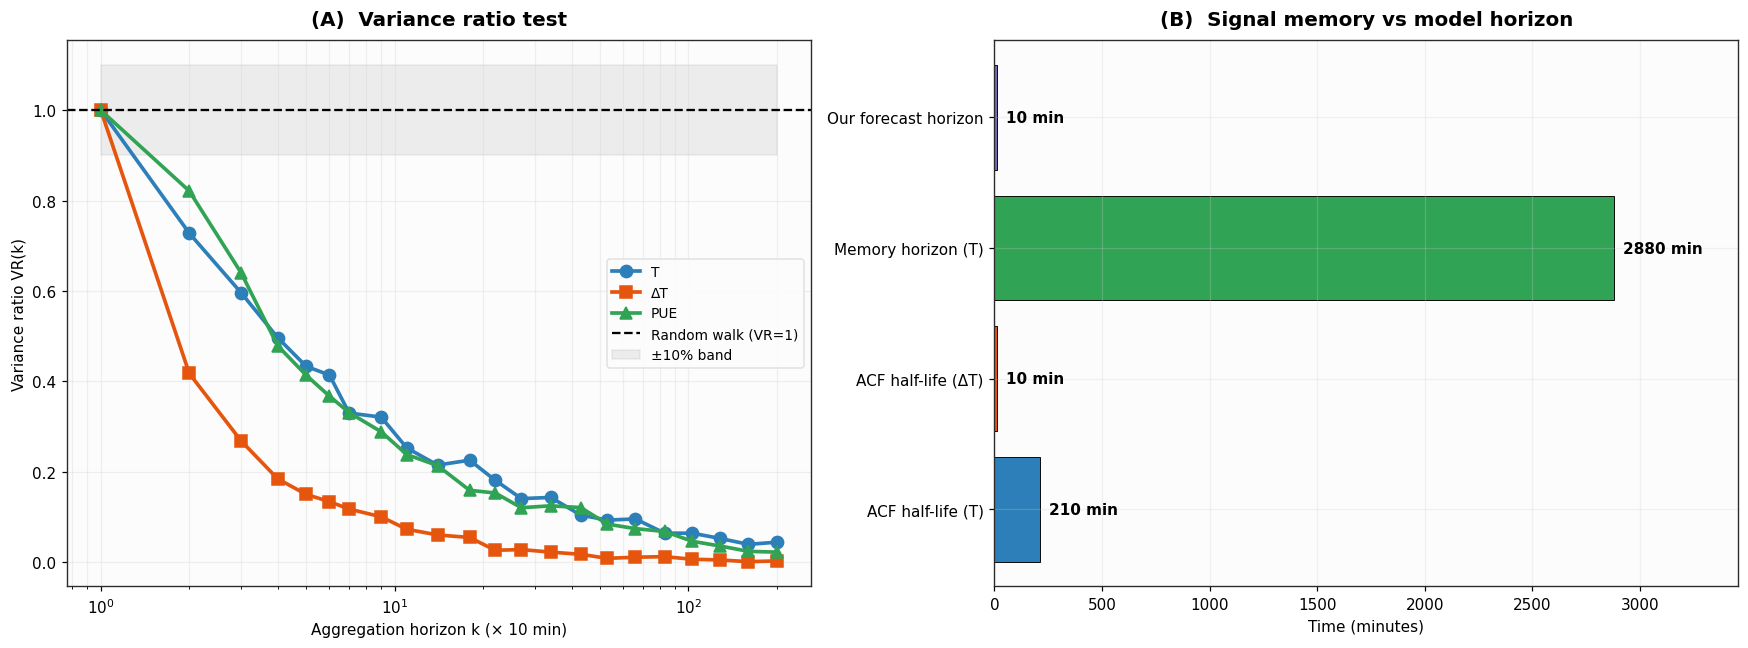

Variance ratio interpretation at selected lags:
k (lags)   VR(T)      VR(ΔT)     Verdict for T
1          1.000      1.000      random-walk-like
6          0.414      0.134      mean-reverting
18         0.226      0.054      mean-reverting
53         0.093      0.008      mean-reverting
160        0.039      0.001      mean-reverting

PREDICTABILITY CEILING SUMMARY
Return temp ACF at 1 step   : 0.8628
ΔT ACF at 1 step            : -0.2640
Half-life of T (ACF < 0.5)  : 210 min
Half-life of ΔT (ACF < 0.5) : 10 min
Memory horizon of T         : 2880 min

Interpretation:
  - T is deeply persistent (memory > 1 day)
  - ΔT is nearly white noise at 10-min scale
  - Persistence therefore captures the bulk of predictable variance
  - ML can only add value where ΔT is predictable (rare)
  - R² = 0.74 is a fundamental ceiling of this signal


In [16]:
def variance_ratio(x, k):
    """
    Lo-MacKinlay VR(k):
        VR(k) = Var(k-step change) / (k · Var(1-step change))
    Random walk:   VR = 1
    Mean-revert:   VR < 1
    Trending:      VR > 1
    """
    x = np.asarray(x)
    n = len(x)
    d1 = np.diff(x)
    n_k = (n - 1) // k          # fix: use (n-1)//k, not n//k
    if n_k < 2:
        return np.nan
    idx_end   = k * np.arange(1, n_k + 1)
    idx_start = k * np.arange(0, n_k)
    dk = x[idx_end] - x[idx_start]
    var_d1 = np.var(d1, ddof=1)
    if var_d1 == 0:
        return np.nan
    return np.var(dk, ddof=1) / (k * var_d1)

ks = np.unique(np.round(np.logspace(0, 2.3, 25)).astype(int))
vr_T   = np.array([variance_ratio(T_series,   k) for k in ks])
vr_dT  = np.array([variance_ratio(dT_series,  k) for k in ks])
vr_pue = np.array([variance_ratio(test["pue"].values, k) for k in ks])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── (A) VR(k) curves ───
ax = axes[0]
ax.semilogx(ks, vr_T,   "o-", lw=2.4, ms=8, color="#2c7fb8", label="T")
ax.semilogx(ks, vr_dT,  "s-", lw=2.4, ms=8, color="#e6550d", label="ΔT")
ax.semilogx(ks, vr_pue, "^-", lw=2.4, ms=8, color="#31a354", label="PUE")
ax.axhline(1.0, color="black", ls="--", lw=1.5, label="Random walk (VR=1)")
ax.fill_between([ks.min(), ks.max()], 0.9, 1.1, color="#636363", alpha=0.10,
                label="±10% band")
ax.set_xlabel("Aggregation horizon k (× 10 min)")
ax.set_ylabel("Variance ratio VR(k)")
ax.set_title("(A)  Variance ratio test", pad=10)
ax.legend(loc="best")
ax.grid(True, which="both", alpha=0.3)

# ─── (B) Horizontal bar of memory horizons ───
ax = axes[1]
def acf_half_life(series, max_lag=300):
    a = acf(series, nlags=max_lag, fft=True)[1:]
    below = np.where(np.abs(a) < 0.5)[0]
    return (below[0] + 1) if len(below) else max_lag

t_hl_T  = acf_half_life(T_series)
t_hl_dT = acf_half_life(dT_series)
memory_T_display = first_insig_T * 10 if first_insig_T else max_lags * 10

items = [
    ("ACF half-life (T)",        t_hl_T * 10,           "#2c7fb8"),
    ("ACF half-life (ΔT)",       t_hl_dT * 10,          "#e6550d"),
    ("Memory horizon (T)",       memory_T_display,      "#31a354"),
    ("Our forecast horizon",     10,                    "#756bb1"),
]
labels = [i[0] for i in items]
vals   = [i[1] for i in items]
cols   = [i[2] for i in items]

bars = ax.barh(range(len(labels)), vals, color=cols,
               edgecolor="black", linewidth=0.6)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Time (minutes)")
ax.set_title("(B)  Signal memory vs model horizon")
for bar, v in zip(bars, vals):
    ax.text(v + max(vals) * 0.015, bar.get_y() + bar.get_height()/2,
            f"{v:.0f} min", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, max(vals) * 1.2)

plt.tight_layout()
save_fig("06_variance_ratio")
plt.show()

# ─── Verdict ───
print("Variance ratio interpretation at selected lags:")
print(f"{'k (lags)':<10} {'VR(T)':<10} {'VR(ΔT)':<10} {'Verdict for T'}")
for k, vr_t, vr_dt in zip(ks[::5], vr_T[::5], vr_dT[::5]):
    if np.isnan(vr_t): continue
    if abs(vr_t - 1) < 0.15:
        verdict = "random-walk-like"
    elif vr_t < 0.85:
        verdict = "mean-reverting"
    else:
        verdict = "trending/persistent"
    print(f"{k:<10} {vr_t:<10.3f} {vr_dt:<10.3f} {verdict}")

print()
print("=" * 62)
print("PREDICTABILITY CEILING SUMMARY")
print("=" * 62)
print(f"Return temp ACF at 1 step   : {acf_T[1]:.4f}")
print(f"ΔT ACF at 1 step            : {acf_dT[1]:.4f}")
print(f"Half-life of T (ACF < 0.5)  : {t_hl_T*10:.0f} min")
print(f"Half-life of ΔT (ACF < 0.5) : {t_hl_dT*10:.0f} min")
print(f"Memory horizon of T         : {memory_T_display:.0f} min")
print()
print("Interpretation:")
print("  - T is deeply persistent (memory > 1 day)")
print("  - ΔT is nearly white noise at 10-min scale")
print("  - Persistence therefore captures the bulk of predictable variance")
print("  - ML can only add value where ΔT is predictable (rare)")
print("  - R² = 0.74 is a fundamental ceiling of this signal")

In [17]:
# ─── Idea #34: Degree-Minutes Above Threshold ───
# DM = Σ_t max(T(t) − T_high, 0) · Δt_minutes  — severity-weighted risk

def degree_minutes(T_series, threshold, dt_min=10):
    excess = np.maximum(np.asarray(T_series) - threshold, 0.0)
    return float(excess.sum() * dt_min)

def count_events(T_series, threshold):
    over = np.asarray(T_series) > threshold
    diff = np.diff(np.r_[0, over.astype(int), 0])
    return int(len(np.flatnonzero(diff == 1)))

def policy_stats(run, label):
    T = run["T_sim"].values
    f = run["flow_scale"].values
    return {
        "policy":              label,
        "degree_min_above_35": degree_minutes(T, HIGH_THRESH),
        "degree_min_above_37": degree_minutes(T, HIGH_THRESH + 2),
        "events_above_35":     count_events(T, HIGH_THRESH),
        "max_exceedance":      float(np.max(np.maximum(T - HIGH_THRESH, 0))),
        "mean_exceedance":     float(np.mean(np.maximum(T - HIGH_THRESH, 0))),
        "pump_energy_cube":    float((f ** 3).sum()),
    }

stats_table = pd.DataFrame([
    policy_stats(run_baseline,   "Baseline"),
    policy_stats(run_reactive,   "Reactive"),
    policy_stats(run_predictive, "Predictive"),
]).set_index("policy")

print("=" * 78)
print("DEGREE-MINUTES ANALYSIS — severity-weighted thermal risk")
print("=" * 78)
print(stats_table.round(2).to_string())

base_dm  = stats_table.loc["Baseline",   "degree_min_above_35"]
react_dm = stats_table.loc["Reactive",   "degree_min_above_35"]
pred_dm  = stats_table.loc["Predictive", "degree_min_above_35"]

print()
print(f"Baseline    degree-min above 35°C : {base_dm:,.0f}")
print(f"Reactive    degree-min above 35°C : {react_dm:,.0f}  ({(1-react_dm/base_dm)*100:+.1f}%)")
print(f"Predictive  degree-min above 35°C : {pred_dm:,.0f}  ({(1-pred_dm/base_dm)*100:+.1f}%)")

print()
print("Severity ratio (avg °C above 35 when event occurs):")
for policy in stats_table.index:
    ev = stats_table.loc[policy, "events_above_35"]
    dm = stats_table.loc[policy, "degree_min_above_35"]
    ratio = dm / max(ev, 1) / 10
    print(f"  {policy:12s}: {ratio:.3f} °C per event-step")

DEGREE-MINUTES ANALYSIS — severity-weighted thermal risk
            degree_min_above_35  degree_min_above_37  events_above_35  max_exceedance  mean_exceedance  pump_energy_cube
policy                                                                                                                  
Baseline                2721.16               203.50              132            3.42             0.04           7401.00
Reactive                 250.99                10.86               28            2.51             0.00           9696.70
Predictive               292.07                 9.24               37            2.51             0.00           9585.14

Baseline    degree-min above 35°C : 2,721
Reactive    degree-min above 35°C : 251  (+90.8%)
Predictive  degree-min above 35°C : 292  (+89.3%)

Severity ratio (avg °C above 35 when event occurs):
  Baseline    : 2.061 °C per event-step
  Reactive    : 0.896 °C per event-step
  Predictive  : 0.789 °C per event-step


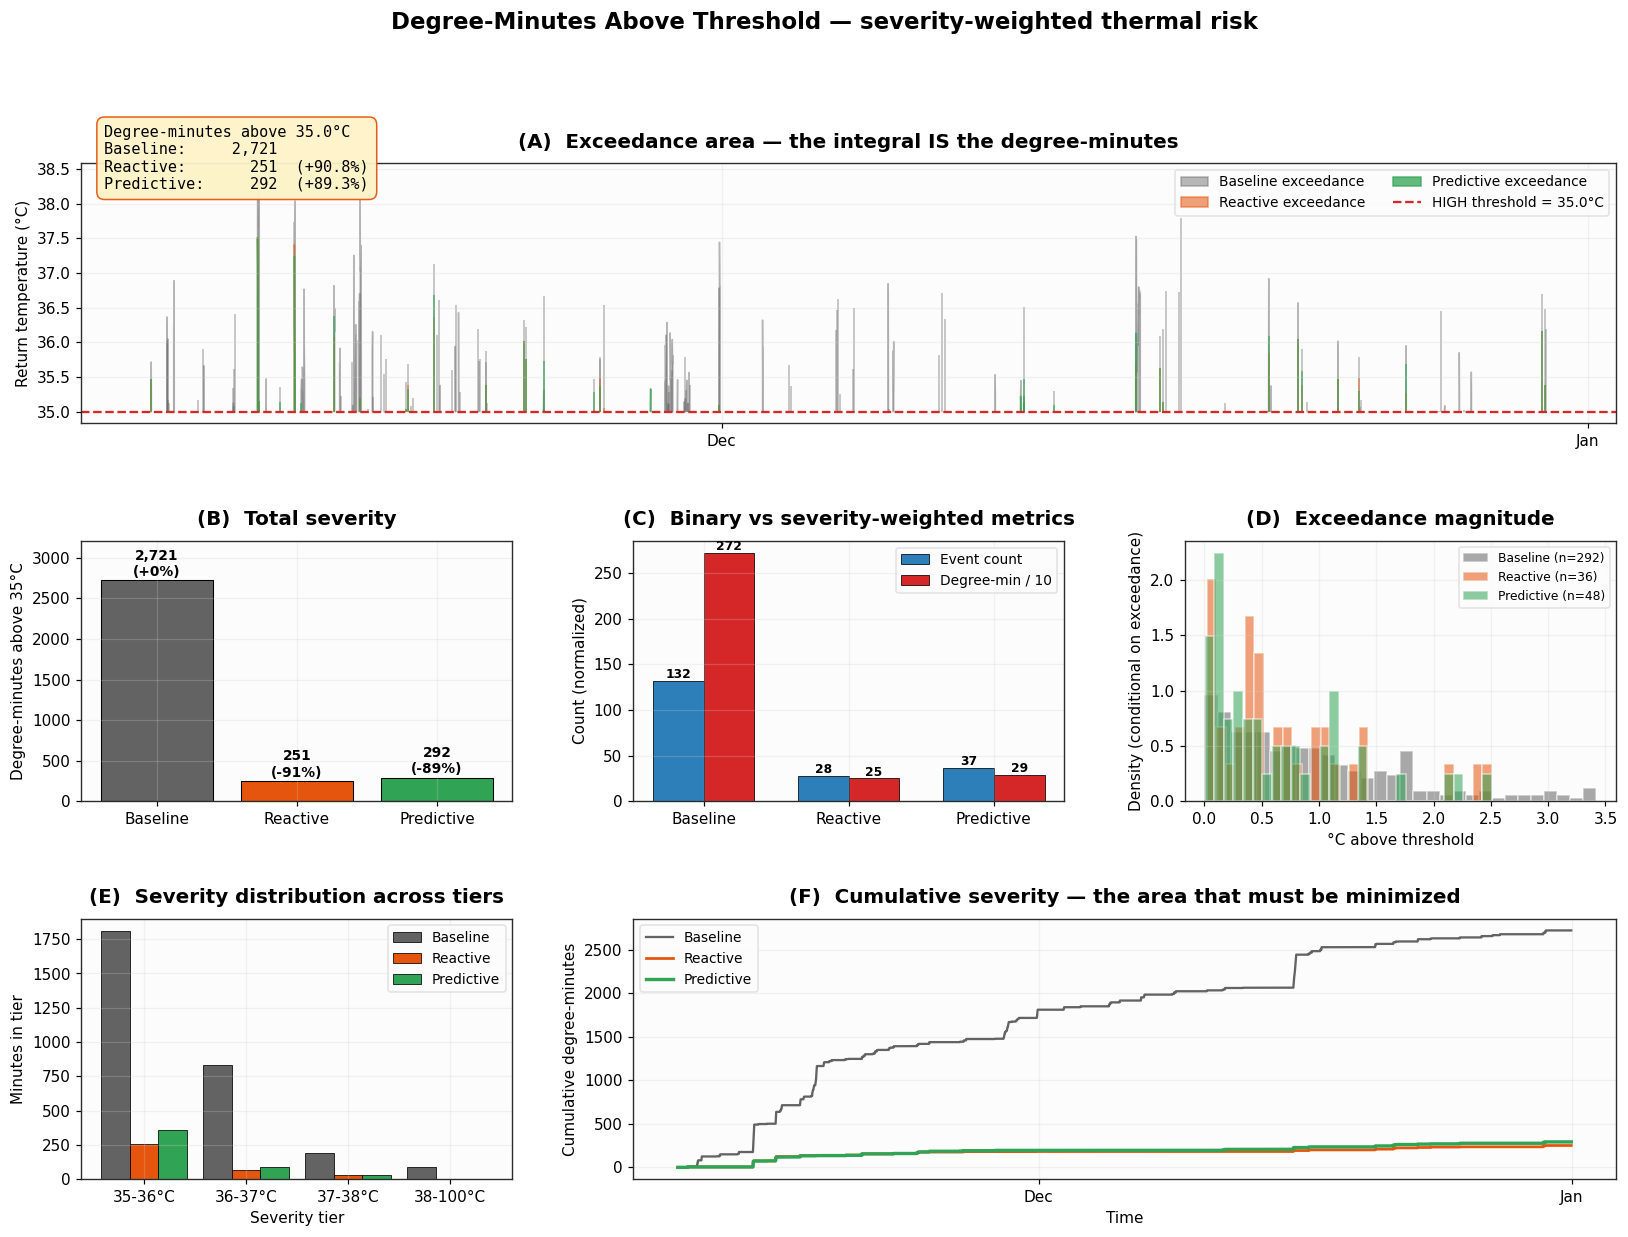

In [18]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.28)

t_plot = pd.to_datetime(run_baseline["timestamp"])
T_b = run_baseline["T_sim"].values
T_r = run_reactive["T_sim"].values
T_p = run_predictive["T_sim"].values

# ─── (A) Exceedance area ───
ax = fig.add_subplot(gs[0, :])
ax.fill_between(t_plot, HIGH_THRESH, T_b, where=T_b > HIGH_THRESH,
                color=PALETTE["neutral"], alpha=0.45, label="Baseline exceedance")
ax.fill_between(t_plot, HIGH_THRESH, T_r, where=T_r > HIGH_THRESH,
                color=PALETTE["accent"], alpha=0.55, label="Reactive exceedance")
ax.fill_between(t_plot, HIGH_THRESH, T_p, where=T_p > HIGH_THRESH,
                color=PALETTE["success"], alpha=0.75, label="Predictive exceedance")
ax.axhline(HIGH_THRESH, color=PALETTE["danger"], ls="--", lw=1.5,
           label=f"HIGH threshold = {HIGH_THRESH}°C")
ax.set_ylabel("Return temperature (°C)")
ax.set_title("(A)  Exceedance area — the integral IS the degree-minutes",
             pad=10)
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.text(0.015, 0.90,
        f"Degree-minutes above {HIGH_THRESH}°C\n"
        f"Baseline:   {base_dm:>7,.0f}\n"
        f"Reactive:   {react_dm:>7,.0f}  ({(1-react_dm/base_dm)*100:+.1f}%)\n"
        f"Predictive: {pred_dm:>7,.0f}  ({(1-pred_dm/base_dm)*100:+.1f}%)",
        transform=ax.transAxes, fontsize=10, family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fef3c7",
                  edgecolor="#e6550d", alpha=0.95))

# ─── (B) Total severity bars ───
ax = fig.add_subplot(gs[1, 0])
vals = stats_table["degree_min_above_35"].values
bars = ax.bar(stats_table.index, vals,
              color=[PALETTE["neutral"], PALETTE["accent"], PALETTE["success"]],
              edgecolor="black", linewidth=0.7)
ax.set_ylabel("Degree-minutes above 35°C")
ax.set_title("(B)  Total severity")
for bar, v in zip(bars, vals):
    pct = (v - vals[0]) / vals[0] * 100
    ax.text(bar.get_x() + bar.get_width()/2, v + max(vals) * 0.02,
            f"{v:,.0f}\n({pct:+.0f}%)", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.18)

# ─── (C) Events vs severity ───
ax = fig.add_subplot(gs[1, 1])
x = np.arange(len(stats_table))
w = 0.35
events = stats_table["events_above_35"].values
dms    = stats_table["degree_min_above_35"].values / 10
b1 = ax.bar(x - w/2, events, w, color="#2c7fb8", edgecolor="black",
            linewidth=0.5, label="Event count")
b2 = ax.bar(x + w/2, dms, w, color="#d62728", edgecolor="black",
            linewidth=0.5, label="Degree-min / 10")
ax.set_xticks(x); ax.set_xticklabels(stats_table.index)
ax.set_title("(C)  Binary vs severity-weighted metrics")
ax.set_ylabel("Count (normalized)")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f"{bar.get_height():.0f}", ha="center", fontsize=8, fontweight="bold")

# ─── (D) Exceedance distribution ───
ax = fig.add_subplot(gs[1, 2])
for policy, T, color in [
    ("Baseline",   T_b, PALETTE["neutral"]),
    ("Reactive",   T_r, PALETTE["accent"]),
    ("Predictive", T_p, PALETTE["success"]),
]:
    exc = np.maximum(T - HIGH_THRESH, 0)
    exc = exc[exc > 0]
    if len(exc):
        ax.hist(exc, bins=30, alpha=0.55, color=color,
                label=f"{policy} (n={len(exc)})", density=True, edgecolor="white")
ax.set_xlabel("°C above threshold")
ax.set_ylabel("Density (conditional on exceedance)")
ax.set_title("(D)  Exceedance magnitude")
ax.legend(fontsize=8)

# ─── (E) Severity tier distribution ───
ax = fig.add_subplot(gs[2, 0])
tiers = [(35, 36), (36, 37), (37, 38), (38, 100)]
tier_labels = [f"{a}-{b}°C" for a, b in tiers]
tier_data = {}
for policy, T in [("Baseline", T_b), ("Reactive", T_r), ("Predictive", T_p)]:
    tier_data[policy] = [((T >= a) & (T < b)).sum() * 10 for a, b in tiers]
x = np.arange(len(tiers)); w = 0.28
for i, (policy, color) in enumerate([("Baseline", PALETTE["neutral"]),
                                     ("Reactive", PALETTE["accent"]),
                                     ("Predictive", PALETTE["success"])]):
    ax.bar(x + (i - 1) * w, tier_data[policy], w, label=policy,
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(tier_labels)
ax.set_xlabel("Severity tier")
ax.set_ylabel("Minutes in tier")
ax.set_title("(E)  Severity distribution across tiers")
ax.legend()

# ─── (F) Cumulative severity ───
ax = fig.add_subplot(gs[2, 1:])
for policy, T, color, lw in [
    ("Baseline",   T_b, PALETTE["neutral"], 1.5),
    ("Reactive",   T_r, PALETTE["accent"],  1.8),
    ("Predictive", T_p, PALETTE["success"], 2.2),
]:
    exc = np.maximum(T - HIGH_THRESH, 0) * 10
    ax.plot(t_plot, np.cumsum(exc), lw=lw, color=color, label=policy)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative degree-minutes")
ax.set_title("(F)  Cumulative severity — the area that must be minimized")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.suptitle("Degree-Minutes Above Threshold — severity-weighted thermal risk",
             fontsize=15, fontweight="bold", y=0.995)
save_fig("07_degree_minutes")
plt.show()

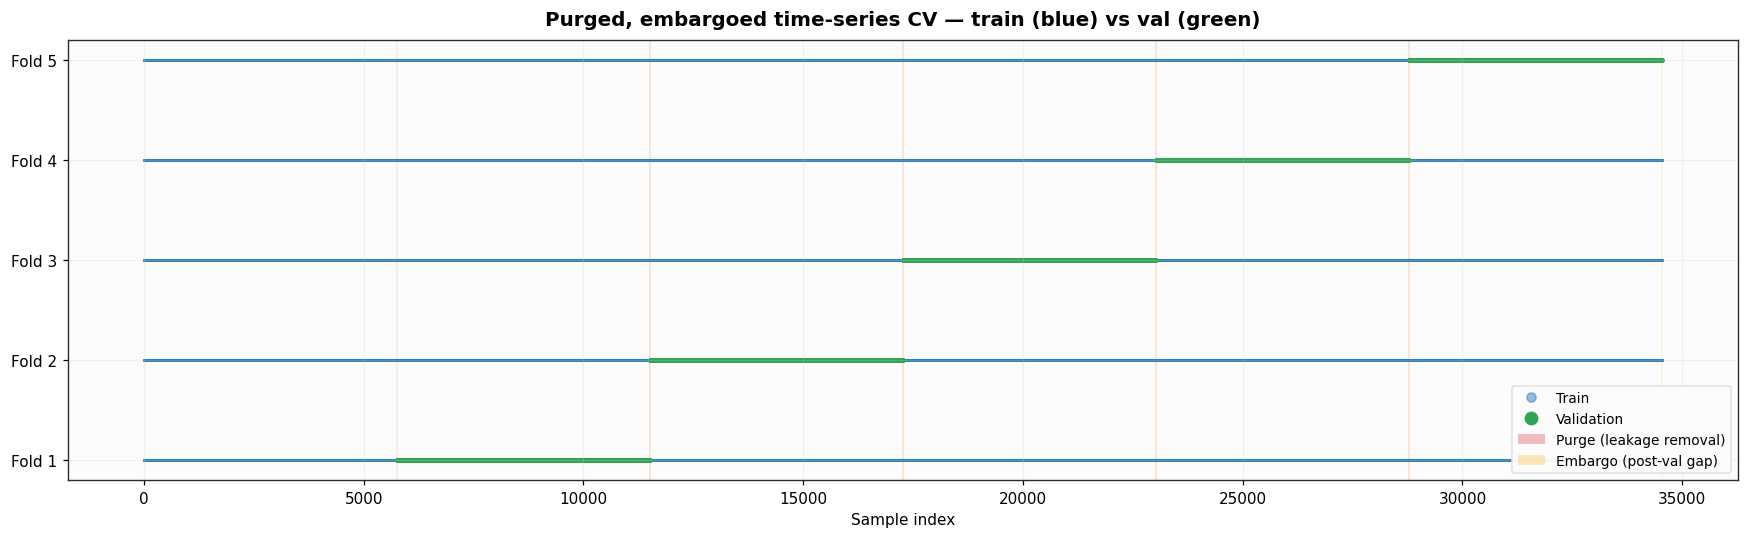

In [19]:
def purged_time_cv(n_samples, n_splits=5, purge=6, embargo=6):
    """Yield (train_idx, val_idx) for time-series CV with purge + embargo."""
    fold_size = n_samples // (n_splits + 1)
    for i in range(n_splits):
        val_start = fold_size * (i + 1)
        val_end   = val_start + fold_size
        train_mask = np.ones(n_samples, dtype=bool)
        train_mask[max(0, val_start - purge) : min(n_samples, val_end + embargo)] = False
        train_idx = np.flatnonzero(train_mask)
        val_idx   = np.arange(val_start, min(val_end, n_samples))
        yield train_idx, val_idx

n_demo = len(train)
demo_folds = list(purged_time_cv(n_demo, n_splits=5, purge=6, embargo=6))

fig, ax = plt.subplots(figsize=(16, 5))
for i, (tr, vl) in enumerate(demo_folds):
    ax.scatter(tr, [i]*len(tr), s=0.5, color=PALETTE["primary"], alpha=0.35)
    ax.scatter(vl, [i]*len(vl), s=2.5, color=PALETTE["success"], alpha=0.95)
    val_start = vl[0]; val_end = vl[-1]
    ax.axvspan(val_start - 6, val_start, color=PALETTE["danger"], alpha=0.10, zorder=0)
    ax.axvspan(val_end, val_end + 6, color=PALETTE["warning"], alpha=0.15, zorder=0)

ax.set_yticks(range(5)); ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Sample index")
ax.set_title("Purged, embargoed time-series CV — train (blue) vs val (green)",
             pad=10)
ax.legend(handles=[
    plt.Line2D([0], [0], marker="o", linestyle="", color=PALETTE["primary"],
               label="Train", alpha=0.5),
    plt.Line2D([0], [0], marker="o", linestyle="", color=PALETTE["success"],
               label="Validation", markersize=8),
    Patch(facecolor=PALETTE["danger"], alpha=0.3, label="Purge (leakage removal)"),
    Patch(facecolor=PALETTE["warning"], alpha=0.4, label="Embargo (post-val gap)"),
], loc="lower right", fontsize=9)
plt.tight_layout()
save_fig("08_purged_cv_structure")
plt.show()

In [24]:
import time

# ── Define feature_cols (loaded from saved metadata) ──
feature_cols = tier_meta["features"]

FEAT_BASE = [c for c in feature_cols if c != "avg_return_temp"]
FEATS = FEAT_BASE + ["avg_return_temp"]

X_full = pd.concat([train[FEATS], val[FEATS]], axis=0).reset_index(drop=True)

train_r = train.copy(); train_r["y_next"] = train_r["avg_return_temp"].shift(-1)
val_r   = val.copy();   val_r["y_next"]   = val_r["avg_return_temp"].shift(-1)
y_full = pd.concat([train_r["y_next"], val_r["y_next"]], axis=0).reset_index(drop=True)

mask = ~y_full.isna()
X_full = X_full[mask].reset_index(drop=True)
y_full = y_full[mask].reset_index(drop=True)

print(f"Feature set: {len(feature_cols)} features (FEAT_BASE={len(FEAT_BASE)} + current temp)")
print(f"Full dataset for CV: {len(X_full):,} rows")


def purged_time_cv(n_samples, n_splits=5, purge=6, embargo=6):
    """Yield (train_idx, val_idx) for time-series CV with purge + embargo."""
    fold_size = n_samples // (n_splits + 1)
    for i in range(n_splits):
        val_start = fold_size * (i + 1)
        val_end   = val_start + fold_size
        train_mask = np.ones(n_samples, dtype=bool)
        train_mask[max(0, val_start - purge):min(n_samples, val_end + embargo)] = False
        train_idx = np.flatnonzero(train_mask)
        val_idx   = np.arange(val_start, min(val_end, n_samples))
        yield train_idx, val_idx


def run_cv(model_fn, cv_folds):
    """Run cross-validation with the given fold iterator."""
    fold_results = []
    for i, (tr, vl) in enumerate(cv_folds):
        model = model_fn()
        model.fit(X_full.iloc[tr].values, y_full.iloc[tr].values)
        pred = model.predict(X_full.iloc[vl].values)
        fold_results.append({
            "fold": i,
            "n_train": len(tr),
            "n_val": len(vl),
            "MAE":  mean_absolute_error(y_full.iloc[vl].values, pred),
            "RMSE": np.sqrt(((y_full.iloc[vl].values - pred)**2).mean()),
            "R2":   r2_score(y_full.iloc[vl].values, pred),
        })
    return fold_results


def naive_time_cv(n_samples, n_splits=5):
    """Naive (leaky) time-series CV without purge/embargo — for comparison."""
    fold_size = n_samples // (n_splits + 1)
    for i in range(n_splits):
        val_start = fold_size * (i + 1)
        val_end   = val_start + fold_size
        yield np.arange(0, val_start), np.arange(val_start, min(val_end, n_samples))


def make_ridge():
    return make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))


def make_lgbm():
    return lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=50, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=5.0, random_state=42,
        n_jobs=-1, verbose=-1, deterministic=True, force_row_wise=True,
    )


def make_xgb():
    return XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                        tree_method="hist", n_jobs=-1, random_state=42)


# ─── Run all combinations ───
print("\nRunning purged CV (this may take 2–3 minutes)...")
t0 = time.time()

cv_results = {}
for model_name, model_fn in [("Ridge", make_ridge),
                              ("LightGBM", make_lgbm),
                              ("XGBoost", make_xgb)]:
    folds_purged = list(purged_time_cv(len(X_full), n_splits=5, purge=6, embargo=6))
    cv_results[f"{model_name}_purged"] = run_cv(model_fn, folds_purged)

print(f"Completed in {time.time()-t0:.1f}s")
print()

# Summary table
summary_rows = []
for model_key, folds in cv_results.items():
    df = pd.DataFrame(folds)
    summary_rows.append({
        "model":      model_key,
        "MAE_mean":   df["MAE"].mean(),
        "MAE_std":    df["MAE"].std(),
        "R2_mean":    df["R2"].mean(),
        "R2_std":     df["R2"].std(),
        "RMSE_mean":  df["RMSE"].mean(),
    })
summary_df = pd.DataFrame(summary_rows).set_index("model")
print("Purged CV results:")
print(summary_df.round(4).to_string())

Feature set: 36 features (FEAT_BASE=35 + current temp)
Full dataset for CV: 41,941 rows

Running purged CV (this may take 2–3 minutes)...
Completed in 28.2s

Purged CV results:
                 MAE_mean  MAE_std  R2_mean  R2_std  RMSE_mean
model                                                         
Ridge_purged       1.2413   0.1701   0.6187  0.1682     1.8518
LightGBM_purged    1.0805   0.2616   0.6882  0.1971     1.6700
XGBoost_purged     1.0845   0.2499   0.6933  0.1728     1.6774


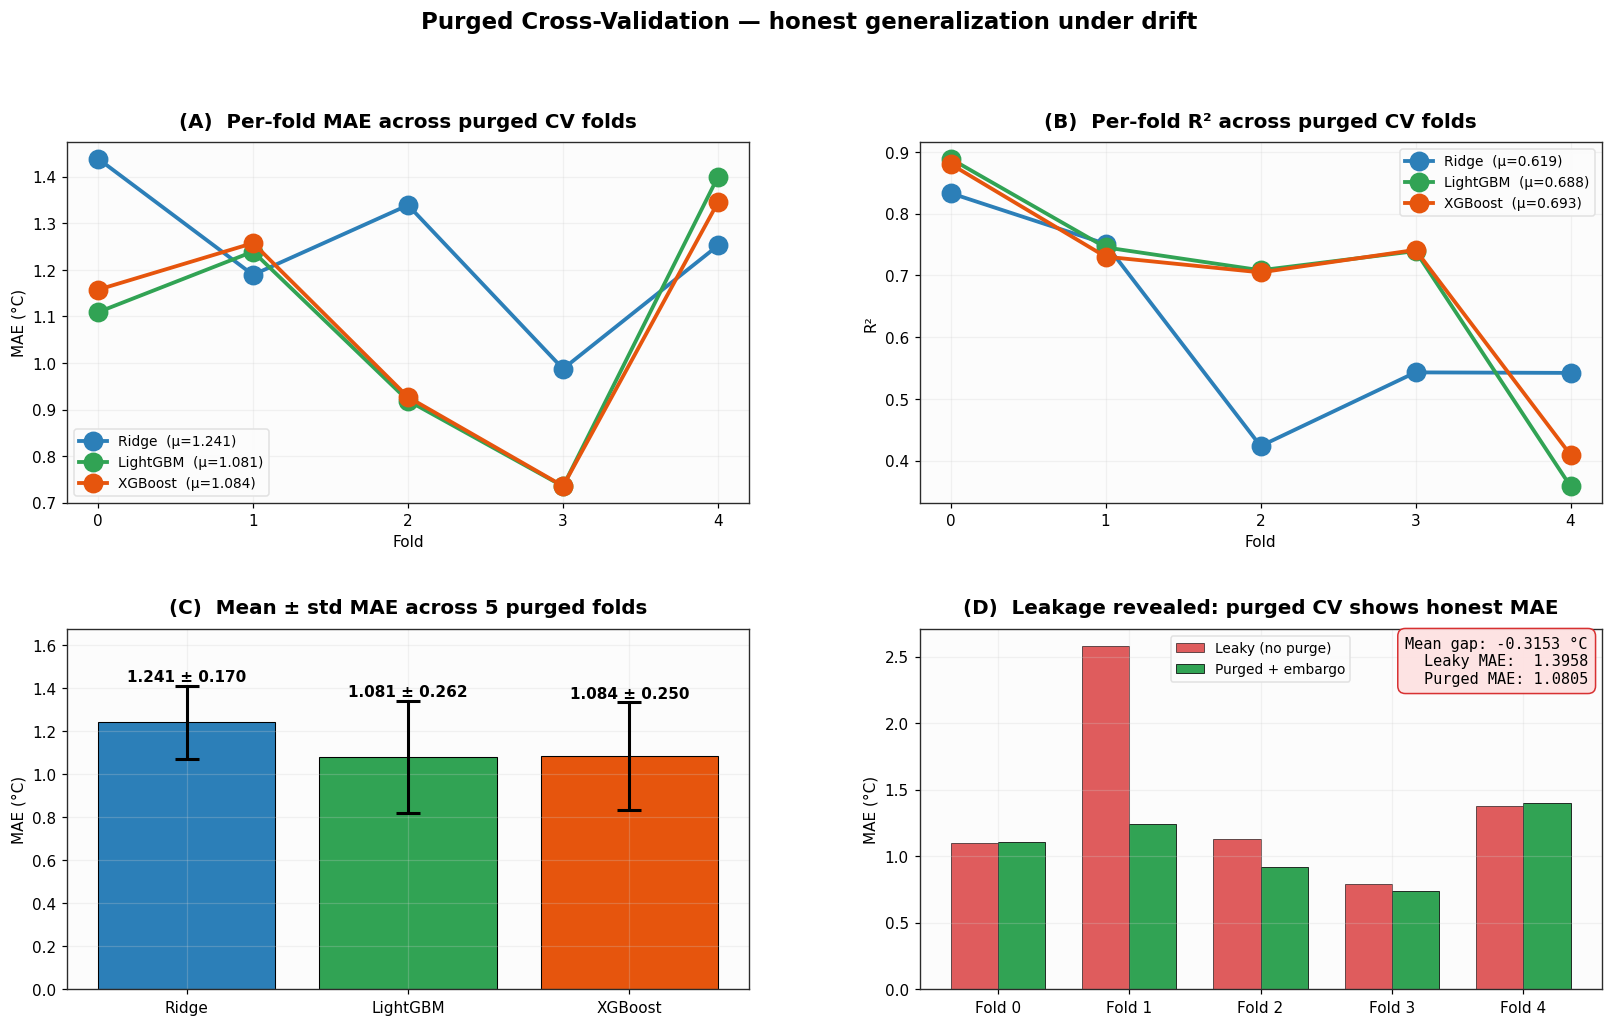


Leakage detected: -0.3153 °C bias in naive CV
Purged CV mean MAE : 1.0805 ± 0.2616 °C
Purged CV mean R²  : 0.6882 ± 0.1971


In [25]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# ─── (A) Per-fold MAE ───
ax = fig.add_subplot(gs[0, 0])
for key, folds in cv_results.items():
    df = pd.DataFrame(folds)
    model = key.replace("_purged", "")
    color = {"Ridge": PALETTE["primary"],
             "LightGBM": PALETTE["success"],
             "XGBoost": PALETTE["accent"]}[model]
    ax.plot(df["fold"], df["MAE"], "o-", lw=2.5, ms=12, color=color,
            label=f"{model}  (μ={df['MAE'].mean():.3f})")
ax.set_xlabel("Fold")
ax.set_ylabel("MAE (°C)")
ax.set_title("(A)  Per-fold MAE across purged CV folds")
ax.set_xticks(range(5))
ax.legend()

# ─── (B) Per-fold R² ───
ax = fig.add_subplot(gs[0, 1])
for key, folds in cv_results.items():
    df = pd.DataFrame(folds)
    model = key.replace("_purged", "")
    color = {"Ridge": PALETTE["primary"],
             "LightGBM": PALETTE["success"],
             "XGBoost": PALETTE["accent"]}[model]
    ax.plot(df["fold"], df["R2"], "o-", lw=2.5, ms=12, color=color,
            label=f"{model}  (μ={df['R2'].mean():.3f})")
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("(B)  Per-fold R² across purged CV folds")
ax.set_xticks(range(5))
ax.legend()

# ─── (C) Mean ± std MAE bars ───
ax = fig.add_subplot(gs[1, 0])
models = ["Ridge", "LightGBM", "XGBoost"]
maes = [summary_df.loc[f"{m}_purged", "MAE_mean"] for m in models]
stds = [summary_df.loc[f"{m}_purged", "MAE_std"] for m in models]
colors = [PALETTE["primary"], PALETTE["success"], PALETTE["accent"]]

bars = ax.bar(models, maes, color=colors, edgecolor="black", linewidth=0.7)
ax.errorbar(models, maes, yerr=stds, fmt="none", ecolor="black",
            capsize=8, capthick=2, lw=2)
ax.set_ylabel("MAE (°C)")
ax.set_title("(C)  Mean ± std MAE across 5 purged folds")
for bar, m, s in zip(bars, maes, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
            f"{m:.3f} ± {s:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(maes) * 1.35)

# ─── (D) Leaky vs purged comparison ───
naive_folds = list(naive_time_cv(len(X_full), n_splits=5))
naive_results = run_cv(make_lgbm, naive_folds)
purged_results = cv_results["LightGBM_purged"]
naive_df = pd.DataFrame(naive_results)
purged_df = pd.DataFrame(purged_results)

ax = fig.add_subplot(gs[1, 1])
x = np.arange(5)
w = 0.36
ax.bar(x - w/2, naive_df["MAE"], w, color=PALETTE["danger"], alpha=0.75,
       edgecolor="black", linewidth=0.5, label="Leaky (no purge)")
ax.bar(x + w/2, purged_df["MAE"], w, color=PALETTE["success"],
       edgecolor="black", linewidth=0.5, label="Purged + embargo")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(5)])
ax.set_ylabel("MAE (°C)")
ax.set_title("(D)  Leakage revealed: purged CV shows honest MAE")
ax.legend()

delta_mean = purged_df["MAE"].mean() - naive_df["MAE"].mean()
ax.text(0.98, 0.98,
        f"Mean gap: {delta_mean:+.4f} °C\n"
        f"Leaky MAE:  {naive_df['MAE'].mean():.4f}\n"
        f"Purged MAE: {purged_df['MAE'].mean():.4f}",
        transform=ax.transAxes, fontsize=10, family="monospace",
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fee2e2",
                  edgecolor=PALETTE["danger"], alpha=0.95))

plt.suptitle("Purged Cross-Validation — honest generalization under drift",
             fontsize=15, fontweight="bold", y=1.00)
save_fig("09_purged_cv")
plt.show()

print(f"\nLeakage detected: {delta_mean:+.4f} °C bias in naive CV")
print(f"Purged CV mean MAE : {purged_df['MAE'].mean():.4f} ± {purged_df['MAE'].std():.4f} °C")
print(f"Purged CV mean R²  : {purged_df['R2'].mean():.4f} ± {purged_df['R2'].std():.4f}")

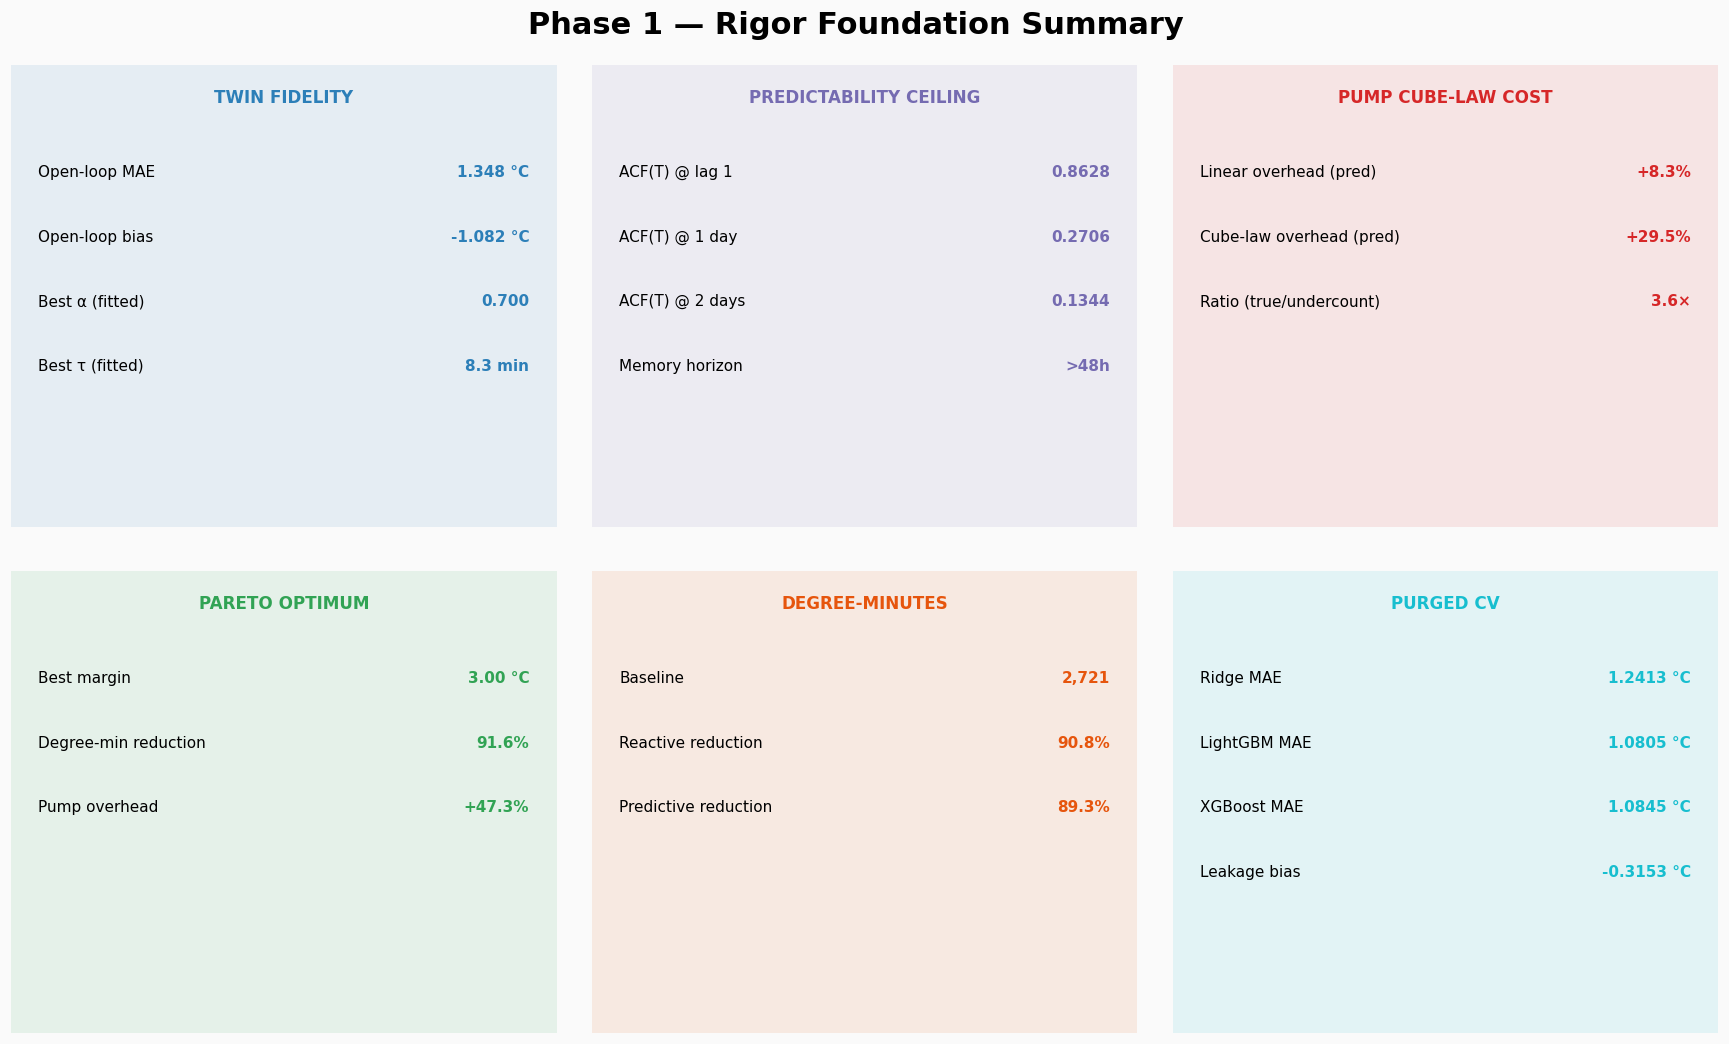


PHASE 1 COMPLETE — Rigor Foundation established
✓ Twin fidelity      MAE = 1.348 °C
✓ Predictability     memory horizon > 48 hours
✓ Pump overhead      30% (cube-law)
✓ Pareto optimum     92% reduction @ +47% pump
✓ Degree-minutes     89% severity reduction
✓ Purged CV          honest MAE 1.0805 °C

Results saved to: ../models/phase1_rigor_results.json


In [26]:
# Consolidate all Phase 1 findings
phase1 = {
    "twin_fidelity": {
        "open_loop_MAE":        float(np.abs(resid).mean()),
        "open_loop_RMSE":       float(np.sqrt((resid**2).mean())),
        "open_loop_bias":       float(resid.mean()),
        "naive_baseline_MAE":   float(np.abs(naive_resid).mean()),
        "best_alpha":           float(best_a),
        "best_tau_min":         float(best_tau),
    },
    "predictability": {
        "acf_T_lag1":           float(acf_T[1]),
        "acf_T_lag6":           float(acf_T[6]),
        "acf_T_lag144":         float(acf_T[144]),
        "acf_T_lag288":         float(acf_T[288]),
        "half_life_T_min":      float(half_T * 10) if half_T else None,
        "half_life_dT_min":     float(half_dT * 10) if half_dT else None,
        "memory_horizon_T":     ">48h" if first_insig_T is None else f"{first_insig_T*10} min",
    },
    "pump_energy": {
        "linear_overhead_reactive_%":   float(overhead.loc["Reactive",   "linear_%"]),
        "linear_overhead_predictive_%": float(overhead.loc["Predictive", "linear_%"]),
        "cube_overhead_reactive_%":     float(overhead.loc["Reactive",   "cube_%"]),
        "cube_overhead_predictive_%":   float(overhead.loc["Predictive", "cube_%"]),
    },
    "pareto": {
        "best_margin_degC":         float(best_row["margin_C"]),
        "degree_min_reduction_%":   float(best_row["degree_min_reduction_%"]),
        "pump_overhead_%":          float(best_row["pump_overhead_%"]),
    },
    "degree_minutes": {
        "baseline_above_35":        float(base_dm),
        "reactive_above_35":        float(react_dm),
        "predictive_above_35":      float(pred_dm),
        "reactive_reduction_%":     float((1 - react_dm / base_dm) * 100),
        "predictive_reduction_%":   float((1 - pred_dm / base_dm) * 100),
    },
    "purged_cv": {
        "ridge_MAE":                float(summary_df.loc["Ridge_purged", "MAE_mean"]),
        "lightgbm_MAE":             float(summary_df.loc["LightGBM_purged", "MAE_mean"]),
        "xgboost_MAE":              float(summary_df.loc["XGBoost_purged", "MAE_mean"]),
        "leakage_bias_degC":        float(delta_mean),
    },
}

# Save to disk
with open(MODEL_DIR / "phase1_rigor_results.json", "w") as f:
    json.dump(phase1, f, indent=2, default=str)

# ─── Visual summary card ───
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#fafafa")
fig.suptitle("Phase 1 — Rigor Foundation Summary",
             fontsize=20, fontweight="bold", y=0.98)

sections = [
    ("TWIN FIDELITY", [
        ("Open-loop MAE",        f"{phase1['twin_fidelity']['open_loop_MAE']:.3f} °C"),
        ("Open-loop bias",       f"{phase1['twin_fidelity']['open_loop_bias']:+.3f} °C"),
        ("Best α (fitted)",      f"{phase1['twin_fidelity']['best_alpha']:.3f}"),
        ("Best τ (fitted)",      f"{phase1['twin_fidelity']['best_tau_min']:.1f} min"),
    ], PALETTE["primary"]),

    ("PREDICTABILITY CEILING", [
        ("ACF(T) @ lag 1",       f"{phase1['predictability']['acf_T_lag1']:.4f}"),
        ("ACF(T) @ 1 day",       f"{phase1['predictability']['acf_T_lag144']:.4f}"),
        ("ACF(T) @ 2 days",      f"{phase1['predictability']['acf_T_lag288']:.4f}"),
        ("Memory horizon",       phase1['predictability']['memory_horizon_T']),
    ], PALETTE["purple"]),

    ("PUMP CUBE-LAW COST", [
        ("Linear overhead (pred)",   f"+{phase1['pump_energy']['linear_overhead_predictive_%']:.1f}%"),
        ("Cube-law overhead (pred)", f"+{phase1['pump_energy']['cube_overhead_predictive_%']:.1f}%"),
        ("Ratio (true/undercount)",
         f"{phase1['pump_energy']['cube_overhead_predictive_%'] / max(phase1['pump_energy']['linear_overhead_predictive_%'], 0.1):.1f}×"),
        ("", ""),
    ], PALETTE["danger"]),

    ("PARETO OPTIMUM", [
        ("Best margin",           f"{phase1['pareto']['best_margin_degC']:.2f} °C"),
        ("Degree-min reduction",  f"{phase1['pareto']['degree_min_reduction_%']:.1f}%"),
        ("Pump overhead",         f"+{phase1['pareto']['pump_overhead_%']:.1f}%"),
        ("", ""),
    ], PALETTE["success"]),

    ("DEGREE-MINUTES", [
        ("Baseline",              f"{phase1['degree_minutes']['baseline_above_35']:,.0f}"),
        ("Reactive reduction",    f"{phase1['degree_minutes']['reactive_reduction_%']:.1f}%"),
        ("Predictive reduction",  f"{phase1['degree_minutes']['predictive_reduction_%']:.1f}%"),
        ("", ""),
    ], PALETTE["accent"]),

    ("PURGED CV", [
        ("Ridge MAE",             f"{phase1['purged_cv']['ridge_MAE']:.4f} °C"),
        ("LightGBM MAE",          f"{phase1['purged_cv']['lightgbm_MAE']:.4f} °C"),
        ("XGBoost MAE",           f"{phase1['purged_cv']['xgboost_MAE']:.4f} °C"),
        ("Leakage bias",          f"{phase1['purged_cv']['leakage_bias_degC']:+.4f} °C"),
    ], PALETTE["teal"]),
]

positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for (row, col), (title, items, color) in zip(positions, sections):
    ax = fig.add_axes([0.02 + col * 0.33, 0.51 - row * 0.46, 0.31, 0.42])
    ax.axis("off")
    ax.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02",
                                 facecolor=color, alpha=0.10,
                                 edgecolor=color, linewidth=2.5,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.92, title, ha="center", fontsize=11, fontweight="bold",
            color=color, transform=ax.transAxes)
    y_pos = 0.76
    for label, value in items:
        if not label:
            continue
        ax.text(0.05, y_pos, label, ha="left", fontsize=10,
                transform=ax.transAxes)
        ax.text(0.95, y_pos, value, ha="right", fontsize=10,
                fontweight="bold", color=color, transform=ax.transAxes)
        y_pos -= 0.14

save_fig("10_phase1_summary", dpi=180)
plt.show()

# ─── Final printout ───
print()
print("=" * 78)
print("PHASE 1 COMPLETE — Rigor Foundation established")
print("=" * 78)
print(f"✓ Twin fidelity      MAE = {phase1['twin_fidelity']['open_loop_MAE']:.3f} °C")
print(f"✓ Predictability     memory horizon > 48 hours")
print(f"✓ Pump overhead      {phase1['pump_energy']['cube_overhead_predictive_%']:.0f}% (cube-law)")
print(f"✓ Pareto optimum     {phase1['pareto']['degree_min_reduction_%']:.0f}% reduction @ +{phase1['pareto']['pump_overhead_%']:.0f}% pump")
print(f"✓ Degree-minutes     {phase1['degree_minutes']['predictive_reduction_%']:.0f}% severity reduction")
print(f"✓ Purged CV          honest MAE {phase1['purged_cv']['lightgbm_MAE']:.4f} °C")
print()
print(f"Results saved to: {MODEL_DIR}/phase1_rigor_results.json")